In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("C:\\Users\\aryan\\ML_COLLEGE\\Sleep_health\\Datasets\\sleep_health_dataset.csv")

In [22]:
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [24]:
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [25]:
df.isna().sum()

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

In [26]:
df.columns

Index(['person_id', 'age', 'gender', 'occupation', 'bmi', 'country',
       'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage',
       'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'chronotype', 'mental_health_condition',
       'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
       'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season',
       'day_type', 'cognitive_performance_score', 'sleep_disorder_risk',
       'felt_rested'],
      dtype='object')

In [27]:
df = df.drop("person_id", axis=1)

In [28]:
le = LabelEncoder()

categorical_cols = [
    'gender',
    'occupation',
    'country',
    'chronotype',
    'mental_health_condition',
    'sleep_aid_used',
    'shift_work',
    'season',
    'day_type',
    'sleep_disorder_risk'  
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [29]:
X = df.drop([
    "sleep_disorder_risk",
    "cognitive_performance_score",
    "felt_rested"
], axis=1)

y = df["sleep_disorder_risk"]

In [30]:
print(X.dtypes)  

age                              int64
gender                           int64
occupation                       int64
bmi                            float64
country                          int64
sleep_duration_hrs             float64
sleep_quality_score            float64
rem_percentage                 float64
deep_sleep_percentage          float64
sleep_latency_mins               int64
wake_episodes_per_night          int64
caffeine_mg_before_bed           int64
alcohol_units_before_bed       float64
screen_time_before_bed_mins      int64
exercise_day                     int64
steps_that_day                   int64
nap_duration_mins                int64
stress_score                   float64
work_hours_that_day            float64
chronotype                       int64
mental_health_condition          int64
heart_rate_resting_bpm           int64
sleep_aid_used                   int64
shift_work                       int64
room_temperature_celsius       float64
weekend_sleep_diff_hrs   

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_resampled.value_counts())

sleep_disorder_risk
0    43264
1    26806
2     6673
3     3257
Name: count, dtype: int64
sleep_disorder_risk
1    43264
0    43264
2    43264
3    43264
Name: count, dtype: int64


In [33]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
y_pred = rf.predict(X_test)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.88735
Precision: 0.8908559965910464
Recall: 0.88735
F1 Score: 0.8887462088774452

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     10892
           1       0.86      0.87      0.87      6673
           2       0.56      0.63      0.59      1626
           3       0.74      0.65      0.69       809

    accuracy                           0.89     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.89      0.89      0.89     20000



In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_resampled, y_train_resampled)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [37]:
y_pred_best = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned Precision:", precision_score(y_test, y_pred_best, average='weighted'))
print("Tuned Recall:", recall_score(y_test, y_pred_best, average='weighted'))
print("Tuned F1:", f1_score(y_test, y_pred_best, average='weighted'))

Tuned Accuracy: 0.88735
Tuned Precision: 0.8908559965910464
Tuned Recall: 0.88735
Tuned F1: 0.8887462088774452


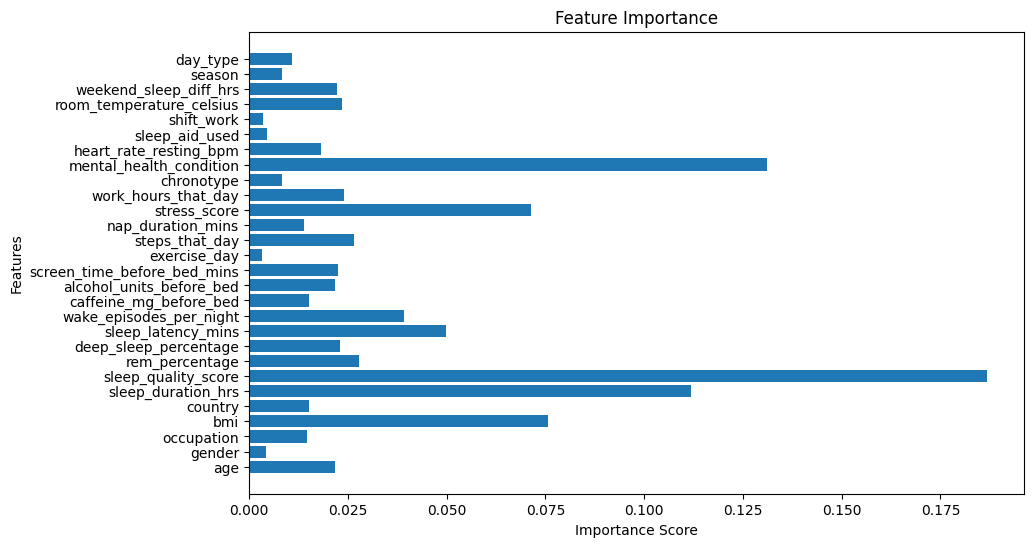

In [40]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.savefig("feature_importance.png")
plt.show()

In [38]:
import joblib

joblib.dump(best_model, "sleep_rf_model.pkl")

['sleep_rf_model.pkl']

In [39]:
model = joblib.load("sleep_rf_model.pkl")

In [41]:
with open("results.txt", "w") as f:
    f.write("Accuracy: " + str(accuracy_score(y_test, y_pred)) + "\n")
    f.write("Precision: " + str(precision_score(y_test, y_pred, average='weighted')) + "\n")
    f.write("Recall: " + str(recall_score(y_test, y_pred, average='weighted')) + "\n")
    f.write("F1 Score: " + str(f1_score(y_test, y_pred, average='weighted')) + "\n\n")
    f.write(classification_report(y_test, y_pred))